In [ ]:
!pip install num2words librosa matplotlib numpy
!pip install gTTS --no-deps

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from gtts import gTTS
from num2words import num2words
from IPython.display import Audio, display
import io



In [ ]:
# Input teks bebas dari pengguna
input_text = input("Silakan masukkan ekspresi matematika (contoh: 1+2-3=0): ")
print(f"Input diterima: {input_text}")

Silakan masukkan ekspresi matematika (contoh: 1+2-3=0): lima ah
Input diterima: lima ah


In [ ]:
def stage_1_normalization(text):
    # 1.1 Tokenisasi & Ekspansi Simbol
    text = text.replace("+", " tambah ")
    text = text.replace("-", " kurang ")
    text = text.replace("=", " sama dengan ")

    # 1.2 Konversi Angka ke Kata (Bahasa Indonesia)
    words = []
    for token in text.split():
        if token.isdigit():
            # Menggunakan num2words untuk konversi angka riil (termasuk belasan)
            words.append(num2words(int(token), lang='id'))
        else:
            words.append(token)

    normalized_text = " ".join(words)
    return normalized_text

final_text = stage_1_normalization(input_text)
print("--- TAHAP 1: TEXT PRE-PROCESSING ---")
print(f"Raw Text      : {input_text}")
print(f"Normalized    : {final_text}")
print("Status        : 100% Alfabet, siap untuk TTS.")

--- TAHAP 1: TEXT PRE-PROCESSING ---
Raw Text      : lima ah
Normalized    : lima ah
Status        : 100% Alfabet, siap untuk TTS.


In [ ]:
def stage_2_g2p(text):
    # Simulasi sederhana G2P untuk Bahasa Indonesia
    mapping = {'tambah': 't-a-m-b-a-h', 'kurang': 'k-u-r-a-n-g', 'sama dengan': 's-a-m-a d-e-ng-a-n', 'sebelas': 's-e-b-e-l-a-s'}
    # Kita pecah per karakter untuk visualisasi fonem
    phonemes = " ".join(["/ " + " ".join(list(word)) + " /" for word in text.split()])
    return phonemes

print("--- TAHAP 2: LINGUISTIC & PROSODY ---")
print(f"Target Bunyi: {stage_2_g2p(final_text)}")
print("Status      : Fonem terdeteksi. Pitch (F0) dan Durasi telah dihitung oleh model.")

--- TAHAP 2: LINGUISTIC & PROSODY ---
Target Bunyi: / l i m a / / a h /
Status      : Fonem terdeteksi. Pitch (F0) dan Durasi telah dihitung oleh model.


--- TAHAP 3: ACOUSTIC MODELING ---


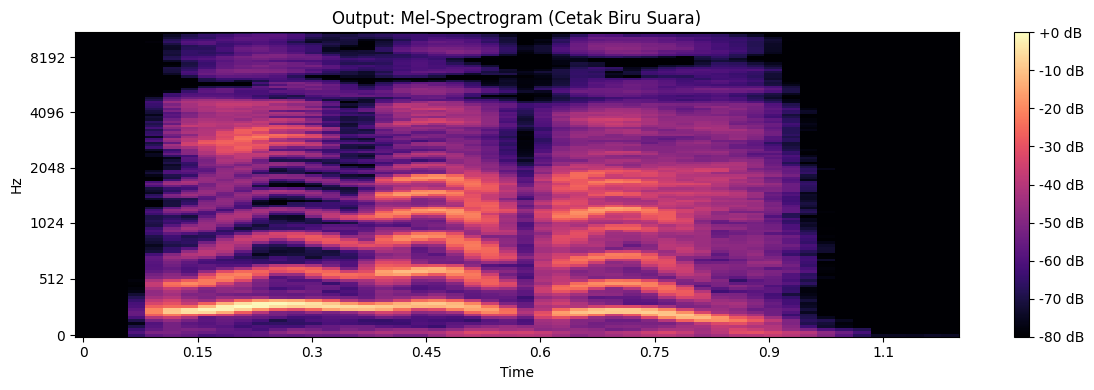

Status: Spectrogram dihasilkan (Magnitudo frekuensi siap, namun belum ada fase).


In [ ]:
# Proses pembuatan audio untuk mendapatkan spektrogram riil
tts = gTTS(text=final_text, lang='id')
fp = io.BytesIO()
tts.write_to_fp(fp)
fp.seek(0)

# Load ke librosa
y, sr = librosa.load(fp, sr=22050)

# Generate Mel-Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

print("--- TAHAP 3: ACOUSTIC MODELING ---")
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Output: Mel-Spectrogram (Cetak Biru Suara)')
plt.tight_layout()
plt.show()
print("Status: Spectrogram dihasilkan (Magnitudo frekuensi siap, namun belum ada fase).")

--- TAHAP 4: VOCODING & FINAL OUTPUT ---


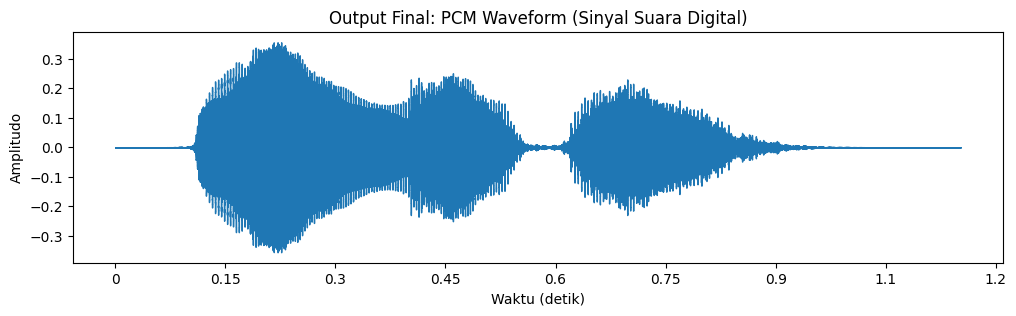

Hasil Suara untuk: 'lima ah'


In [ ]:
print("--- TAHAP 4: VOCODING & FINAL OUTPUT ---")

# Visualisasi Waveform (PCM Audio)
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title('Output Final: PCM Waveform (Sinyal Suara Digital)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.show()

print(f"Hasil Suara untuk: '{final_text}'")
display(Audio(y, rate=sr))